# NB4 — SHAP Explainability

**Upgraded**: Supports all three head types from NB3:
- `ANN`  → GradientSHAP on flat feature vectors → bar charts of sensor statistics
- `LSTM` / `Transformer` → GradientSHAP on raw windows (N, T, S) → per-timestep heatmaps + sensor importance bars

The active model type is read from `checkpoints/nb3_meta.json` — no manual configuration needed.


## 0 — Imports & configuration

In [3]:
import sys, os, pickle, warnings, logging, json
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch

sys.path.insert(0, '..')
from models import (
    ConvAutoencoder, AETrainer,
    MultiHeadANN,
    MultiHeadLSTM,
    MultiHeadTransformer,
    MCDropoutWrapper,
    DEVICE,
)
from feature_engineering import FeaturePipeline
from explainability      import SHAPExplainer
from fault_engine        import FAULT_LABELS

PROC_DIR = '../processed_data'
CKPT_DIR = '../checkpoints'
PLOT_DIR = '../plots'
label_names = {0:'Nominal',1:'Bias',2:'Scaling',3:'Drift',
               4:'Intermittent',5:'Compound',6:'MultiSensor',7:'SystemFault'}

N_BACKGROUND = 200    # background samples for GradientSHAP
N_EXPLAIN    = 50     # windows to explain per class
TOP_K_FEATS  = 15     # top-K features / timestep-sensor pairs per plot

print(f'Device : {DEVICE}')

Device : cuda


## 1 — Load artefacts (auto-detects model type)

In [4]:
with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f:
    sensor_cols = pickle.load(f)

# Read NB3 metadata to know what was trained
with open(f'{CKPT_DIR}/nb3_meta.json') as f:
    meta = json.load(f)

HEAD_TYPE    = meta['head_type']
USE_RESIDUAL = meta['use_residual']
N_SENSORS    = meta['n_sensors']
WINDOW_SIZE  = meta['window_size']
N_FAULT_TYPES= meta['n_fault_types']

print(f'HEAD_TYPE    : {HEAD_TYPE}')
print(f'USE_RESIDUAL : {USE_RESIDUAL}')
print(f'Best val losses from NB3: {meta["best_val_losses"]}')

# ── Raw dataset ──────────────────────────────────────────────────────────────
_raw = np.load(f'{PROC_DIR}/augmented_dataset_with_recon.npz')
X_dataset   = _raw['X']
X_recon_all = _raw['X_rec']
y_fault     = _raw['y_f']
y_sensor    = _raw['y_s']
y_mag       = _raw['y_m']

# ── AE (always needed) ───────────────────────────────────────────────────────
X_nominal = np.load(f'{PROC_DIR}/X_nominal.npy')
ae_model  = ConvAutoencoder(n_sensors=N_SENSORS, window_size=WINDOW_SIZE,
                             base_ch=16, latent_dim=32).to(DEVICE)
ae_model.load_state_dict(torch.load(f'{CKPT_DIR}/autoencoder.pt',
                                     map_location=DEVICE, weights_only=True))
ae_model.eval()
ae_trainer = AETrainer(ae_model, device=DEVICE)

print(f'X_dataset   : {X_dataset.shape}')
print(f'AE loaded.')

HEAD_TYPE    : all
USE_RESIDUAL : True
Best val losses from NB3: {'ANN': 0.893088698387146, 'LSTM': 0.5769222974777222, 'Transformer': 0.9102692604064941}


2026-04-22 14:32:46,325 [INFO] AE Bottleneck: 1664 -> 32 -> 1664


X_dataset   : (112154, 100, 29)
AE loaded.


In [5]:
# ── Load whichever classification model was trained in NB3 ────────────────────
# This cell loads the *best* model according to the HEAD_TYPE flag.
# If HEAD_TYPE == 'all', we prefer LSTM for sequence explainability
# and ANN for flat-feature explainability; both explainers are built.

models_to_explain = []   # list of (name, model, ckpt_path)

# ANN
if HEAD_TYPE in ('ANN', 'all') and os.path.exists(f'{CKPT_DIR}/ann_multihead.pt'):
    _d    = np.load(f'{PROC_DIR}/final_manifold_features.npz')
    F_all = _d['F']
    with open(f'{CKPT_DIR}/feature_pipeline.pkl', 'rb') as f:
        feat_pipe = pickle.load(f)
    ann_model = MultiHeadANN(
        in_features=F_all.shape[1], n_fault_types=N_FAULT_TYPES,
        n_sensors=len(sensor_cols), hidden_dims=[128, 64, 32], dropout_p=0.3
    )
    ann_model.load_state_dict(torch.load(f'{CKPT_DIR}/ann_multihead.pt',
                                          map_location=DEVICE, weights_only=True))
    ann_model.to(DEVICE).eval()
    models_to_explain.append(('ANN', ann_model, F_all))
    print(f'ANN loaded  ({F_all.shape[1]} features)')

# LSTM
if HEAD_TYPE in ('LSTM', 'all') and os.path.exists(f'{CKPT_DIR}/lstm_multihead.pt'):
    cfg = meta['lstm_config']
    lstm_model = MultiHeadLSTM(
        n_sensors=N_SENSORS, hidden_size=cfg['hidden_size'],
        num_layers=cfg['num_layers'], n_fault_types=N_FAULT_TYPES,
        dropout_p=cfg['dropout_p'], use_residual=USE_RESIDUAL,
    )
    lstm_model.load_state_dict(torch.load(f'{CKPT_DIR}/lstm_multihead.pt',
                                            map_location=DEVICE, weights_only=True))
    lstm_model.to(DEVICE).eval()
    if USE_RESIDUAL:
        X_seq = np.concatenate([X_dataset,
                                 np.abs(X_dataset - X_recon_all).astype(np.float32)], axis=-1)
    else:
        X_seq = X_dataset
    models_to_explain.append(('LSTM', lstm_model, X_seq))
    print(f'LSTM loaded  (input shape: {X_seq.shape[1:]})')

# Transformer
if HEAD_TYPE in ('Transformer', 'all') and os.path.exists(f'{CKPT_DIR}/transformer_multihead.pt'):
    cfg = meta['transformer_config']
    tf_model = MultiHeadTransformer(
        n_sensors=N_SENSORS, d_model=cfg['d_model'], nhead=cfg['nhead'],
        num_layers=cfg['num_layers'], dim_feedforward=cfg['dim_feedforward'],
        n_fault_types=N_FAULT_TYPES, dropout_p=cfg['dropout_p'],
        use_residual=USE_RESIDUAL, store_attn=False,
    )
    tf_model.load_state_dict(torch.load(f'{CKPT_DIR}/transformer_multihead.pt',
                                          map_location=DEVICE, weights_only=True))
    tf_model.to(DEVICE).eval()
    if USE_RESIDUAL:
        X_seq_tf = np.concatenate([X_dataset,
                                    np.abs(X_dataset - X_recon_all).astype(np.float32)], axis=-1)
    else:
        X_seq_tf = X_dataset
    # Reuse X_seq if LSTM already computed it with same USE_RESIDUAL setting
    if 'X_seq' not in dir():
        X_seq = X_seq_tf
    models_to_explain.append(('Transformer', tf_model, X_seq_tf))
    print(f'Transformer loaded  (input shape: {X_seq_tf.shape[1:]})')

print(f'\nModels to explain: {[m[0] for m in models_to_explain]}')

ANN loaded  (406 features)
LSTM loaded  (input shape: (100, 58))
Transformer loaded  (input shape: (100, 58))

Models to explain: ['ANN', 'LSTM', 'Transformer']


## 2 — Build SHAP explainers

One `SHAPExplainer` per model. Background samples are drawn from nominal windows (class 0).

In [6]:
nominal_mask = y_fault == 0
shap_explainers = {}

for name, model, X_input in models_to_explain:
    # Background = nominal windows in the model's input space
    background = X_input[nominal_mask]
    print(f'Building {name} SHAPExplainer  background shape: {background.shape}')

    expl = SHAPExplainer(
        model        = model,
        background   = background,
        device       = DEVICE,
        n_background = N_BACKGROUND,
        model_type   = name,
    )
    shap_explainers[name] = (expl, X_input)
    print(f'  → {name} explainer ready')

# Persist all explainers (dict keyed by model name)
import pickle as _pkl
with open(f'{CKPT_DIR}/shap_explainers.pkl', 'wb') as f:
    _pkl.dump(shap_explainers, f)
print(f'\nSaved shap_explainers.pkl  (keys: {list(shap_explainers.keys())})')

Building ANN SHAPExplainer  background shape: (16022, 406)


2026-04-22 14:33:07,956 [INFO] SHAPExplainer [ANN]: GradientSHAP initialised (bg=200, input=(406,))
2026-04-22 14:33:08,109 [INFO] SHAPExplainer [LSTM]: GradientSHAP initialised (bg=200, input=(100, 58))


  → ANN explainer ready
Building LSTM SHAPExplainer  background shape: (16022, 100, 58)
  → LSTM explainer ready


2026-04-22 14:33:08,281 [INFO] SHAPExplainer [Transformer]: GradientSHAP initialised (bg=200, input=(100, 58))


Building Transformer SHAPExplainer  background shape: (16022, 100, 58)
  → Transformer explainer ready

Saved shap_explainers.pkl  (keys: ['ANN', 'LSTM', 'Transformer'])


In [7]:
shap_explainers

{'ANN': (<explainability.SHAPExplainer at 0x1e53a59c110>,
  array([[ 8.7620950e-01,  1.3397040e-04, -1.6592941e-01, ...,
           1.2605715e-01,  1.7328879e-02,  2.2160429e-01],
         [ 7.7429682e-01,  1.5291404e-04, -3.6842430e-01, ...,
           8.8805640e-01,  4.4571239e-01,  3.7027958e-01],
         [ 9.2285341e-01,  8.7553555e-05,  8.0325209e-02, ...,
           2.6714522e-01,  1.9443639e-01,  2.5488341e-01],
         ...,
         [ 7.2641832e-01,  6.1536295e-05,  1.9401979e-01, ...,
           2.4159080e-01,  1.0097692e-01,  1.6657178e-01],
         [ 8.1309181e-01,  4.7063652e-02,  4.5099750e-01, ...,
           3.3760054e+00,  3.1639142e+00,  2.4164691e+00],
         [ 7.7192205e-01,  1.2891118e-04,  8.2727182e-01, ...,
           2.2859900e+00,  6.0362667e-01,  4.8615631e-01]], dtype=float32)),
 'LSTM': (<explainability.SHAPExplainer at 0x1e53a4a3710>,
  array([[[8.76101434e-01, 8.45463157e-01, 6.59691095e-01, ...,
           1.71828449e-01, 7.17065930e-02, 4.95680571e-

## 3a — ANN path: feature importance bar charts

ANN feature names: 232
  ANN SHAP: class 1 (Bias)  50 windows …


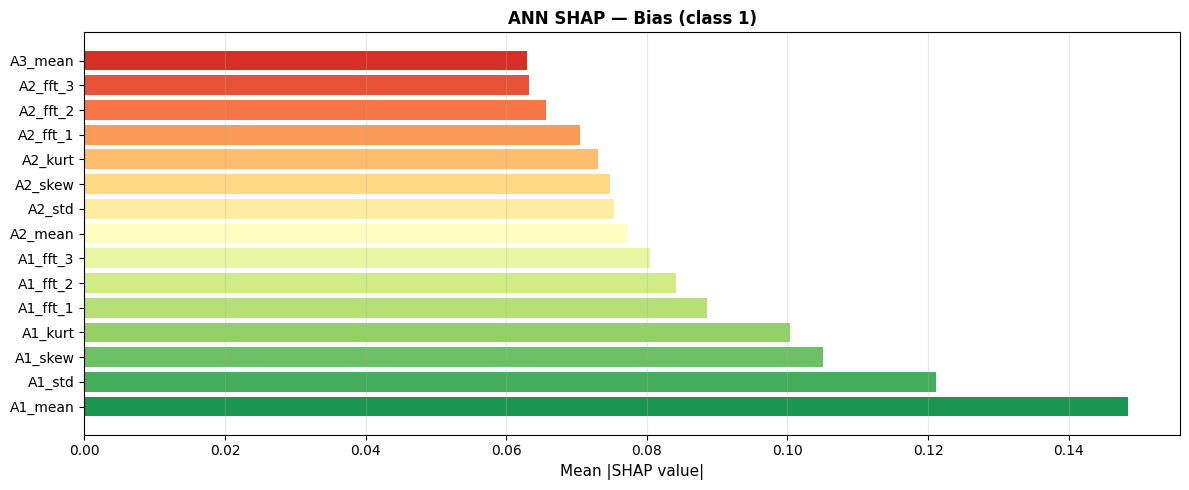

  ANN SHAP: class 2 (Scaling)  50 windows …


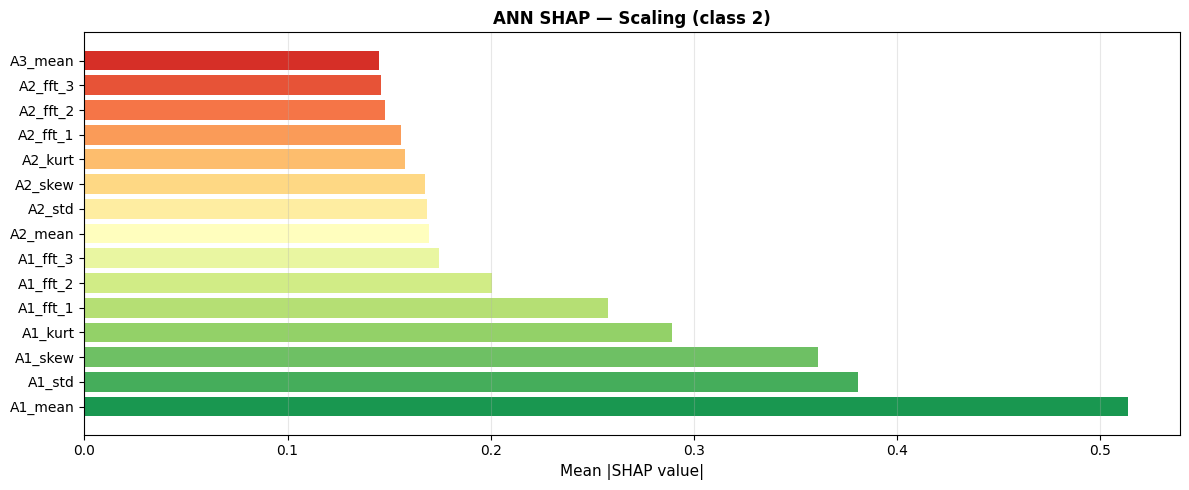

  ANN SHAP: class 3 (Drift)  50 windows …


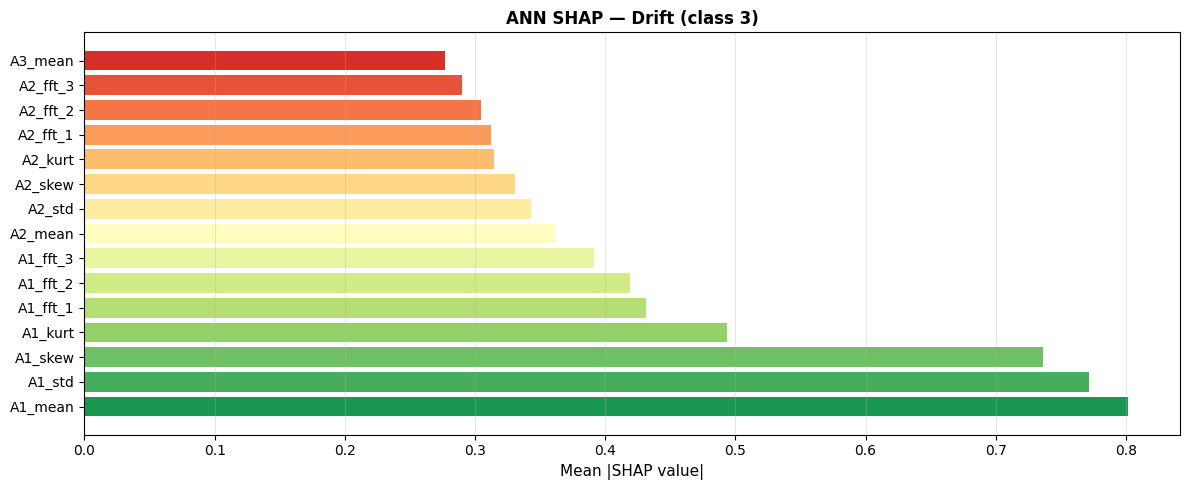

  ANN SHAP: class 4 (Intermittent)  50 windows …


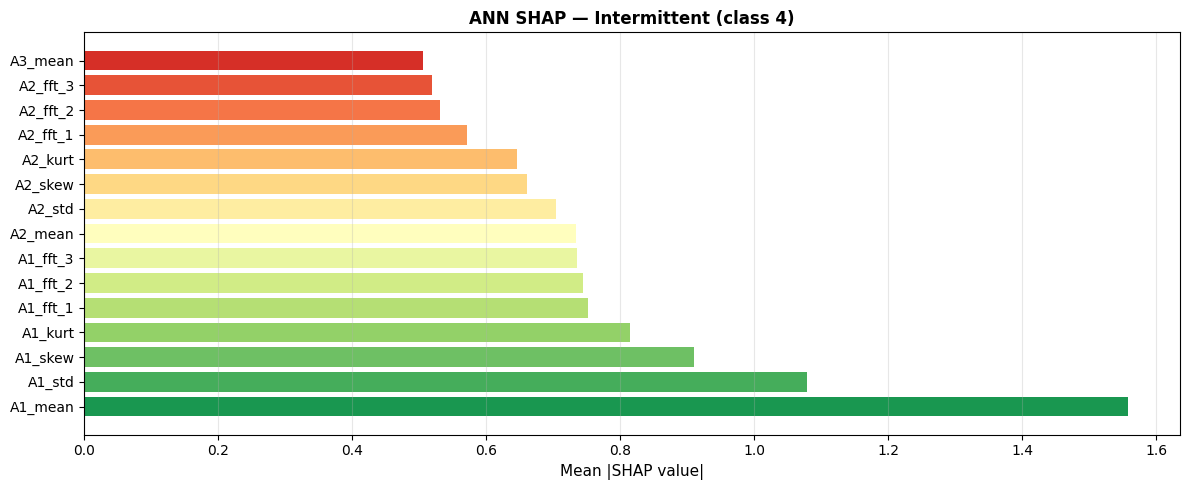

  ANN SHAP: class 5 (Compound)  50 windows …


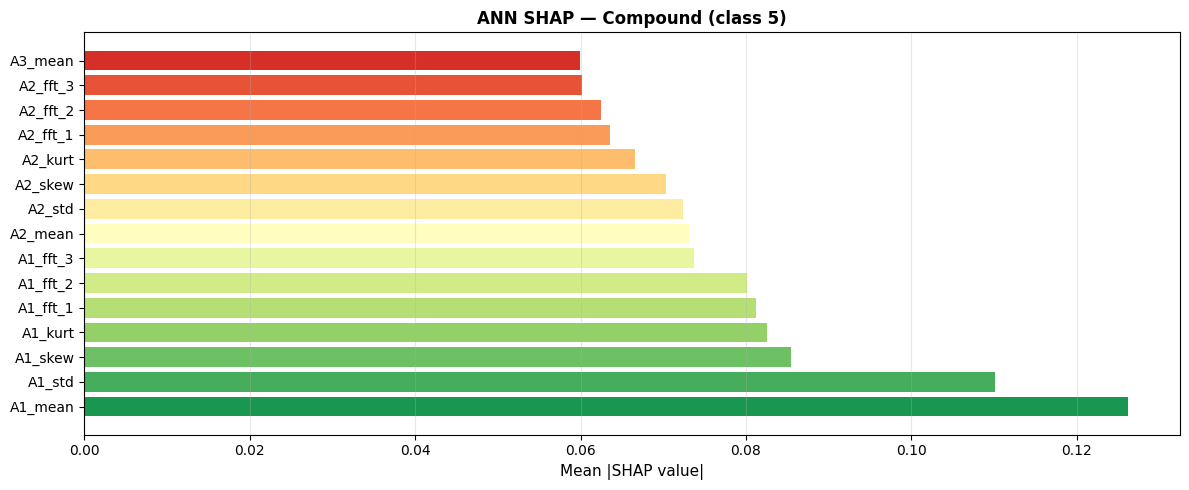

  ANN SHAP: class 6 (MultiSensor)  50 windows …


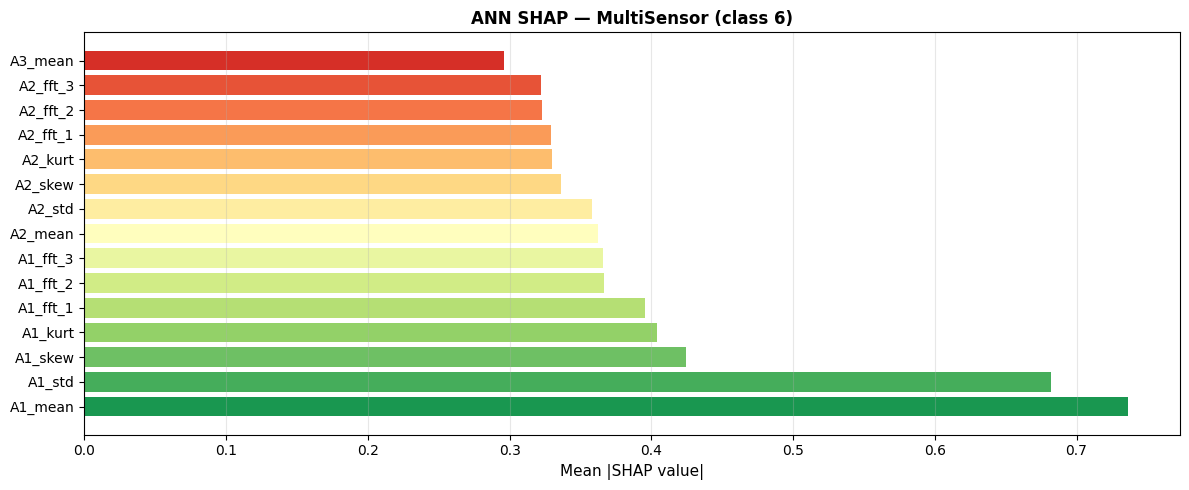

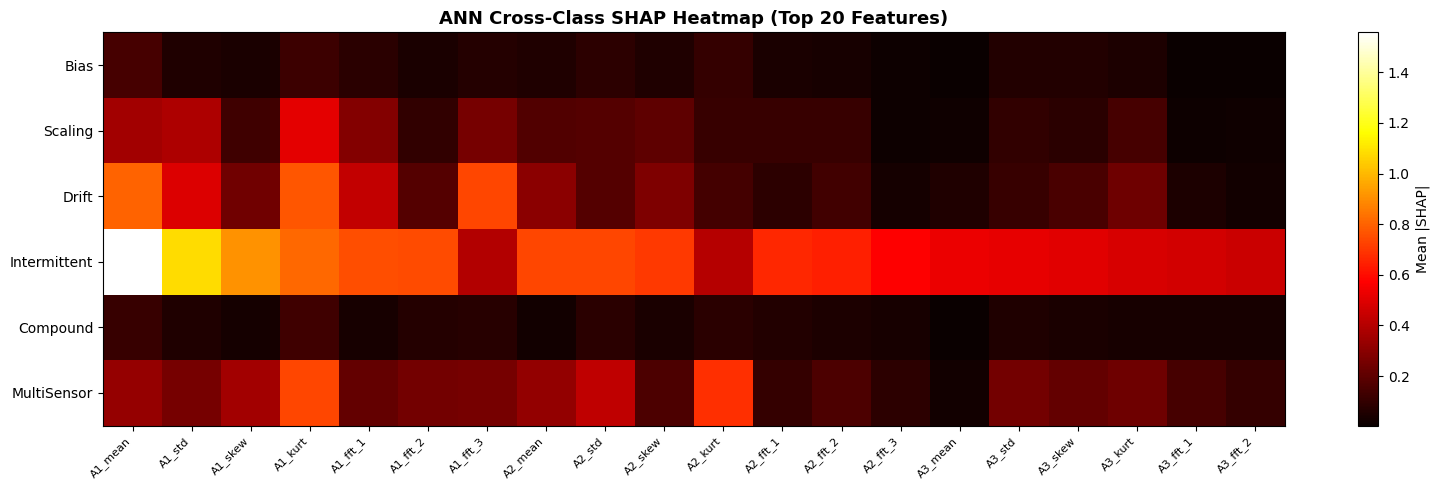

In [8]:
ann_shap_sv = {}   # class_idx → (N, F) SHAP values

if 'ANN' in shap_explainers:
    ann_expl, F_input = shap_explainers['ANN']
    feat_names = SHAPExplainer.feature_names(sensor_cols, n_fft_peaks=3)
    print(f'ANN feature names: {len(feat_names)}')

    for class_idx in sorted(np.unique(y_fault)):
        class_name = label_names.get(class_idx, str(class_idx))
        if class_idx == 0:
            continue   # skip nominal
        mask  = y_fault == class_idx
        F_cls = F_input[mask][:N_EXPLAIN]
        if len(F_cls) < 5:
            continue

        print(f'  ANN SHAP: class {class_idx} ({class_name})  {len(F_cls)} windows …')
        sv, _ = ann_expl.explain(F_cls, top_k=TOP_K_FEATS, class_idx=int(class_idx))
        ann_shap_sv[class_idx] = sv

        mean_abs = np.abs(sv).mean(axis=0)
        top_idx  = np.argsort(mean_abs)[::-1][:TOP_K_FEATS]
        colors_  = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, TOP_K_FEATS))

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.barh([feat_names[i] for i in range(0, len(top_idx))], mean_abs[top_idx], color=colors_)
        ax.set_xlabel('Mean |SHAP value|', fontsize=11)
        ax.set_title(f'ANN SHAP — {class_name} (class {class_idx})',
                     fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{PLOT_DIR}/nb4_ann_shap_{class_name.lower()}.png', dpi=120)
        plt.show()

    # Cross-class heatmap
    if len(ann_shap_sv) >= 2:
        classes_ = sorted(ann_shap_sv.keys())
        mat = np.array([np.abs(ann_shap_sv[c]).mean(axis=0) for c in classes_])
        top20 = np.argsort(mat.max(axis=0))[::-1][:20]
        fig, ax = plt.subplots(figsize=(16, 5))
        im = ax.imshow(mat[:, top20], aspect='auto', cmap='hot', interpolation='nearest')
        ax.set_xticks(range(len(top20)))
        ax.set_xticklabels([feat_names[i] for i in range(0, len(top20))], rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(classes_)))
        ax.set_yticklabels([label_names.get(c, str(c)) for c in classes_])
        ax.set_title('ANN Cross-Class SHAP Heatmap (Top 20 Features)', fontsize=13, fontweight='bold')
        plt.colorbar(im, ax=ax, label='Mean |SHAP|')
        plt.tight_layout()
        plt.savefig(f'{PLOT_DIR}/nb4_ann_shap_heatmap.png', dpi=130)
        plt.show()
else:
    print('ANN not available — skipping ANN SHAP section.')

In [9]:
top20

array([310, 309, 206, 254, 250, 270, 238, 205, 298, 222, 253, 242, 241,
        57,  93,  72, 214, 277, 109,   9], dtype=int64)

## 3b — Sequence path: timestep + sensor importance

For LSTM and Transformer, SHAP values have shape `(N, T, S)`. We visualise them as:
1. **Timestep importance heatmap** — `(N_examples, T)` — *when* in the window the fault is detected
2. **Sensor importance bar** — `|SHAP|` summed over T — *which sensor* drives each fault class


── LSTM SHAP ──────────────────────────────────────────
  LSTM SHAP: class 1 (Bias)  50 windows …


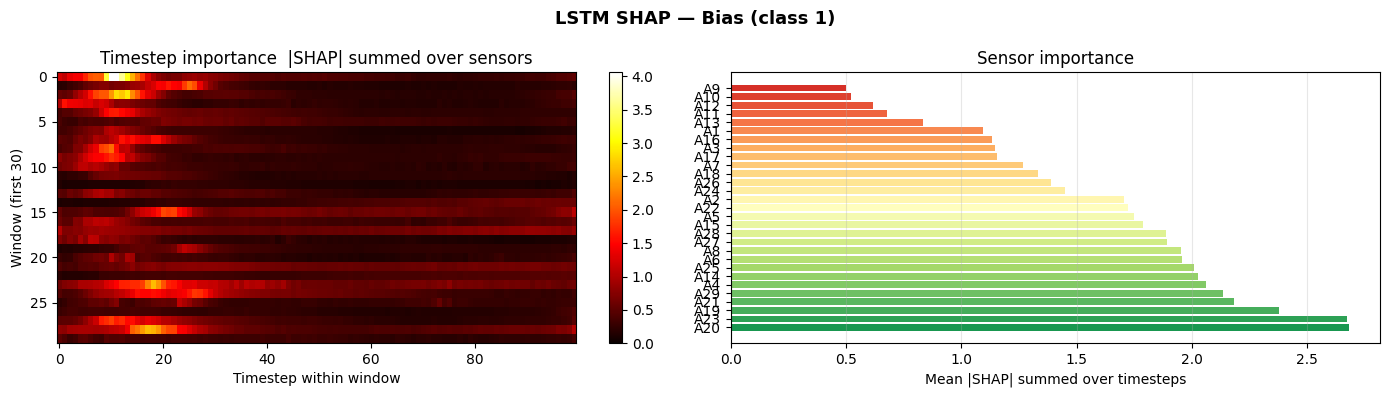

  LSTM SHAP: class 2 (Scaling)  50 windows …


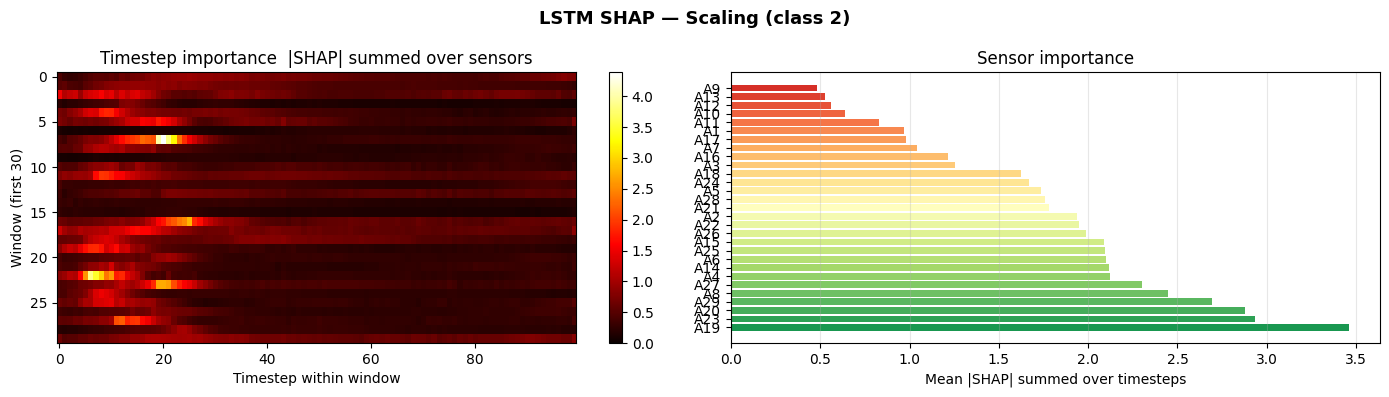

  LSTM SHAP: class 3 (Drift)  50 windows …


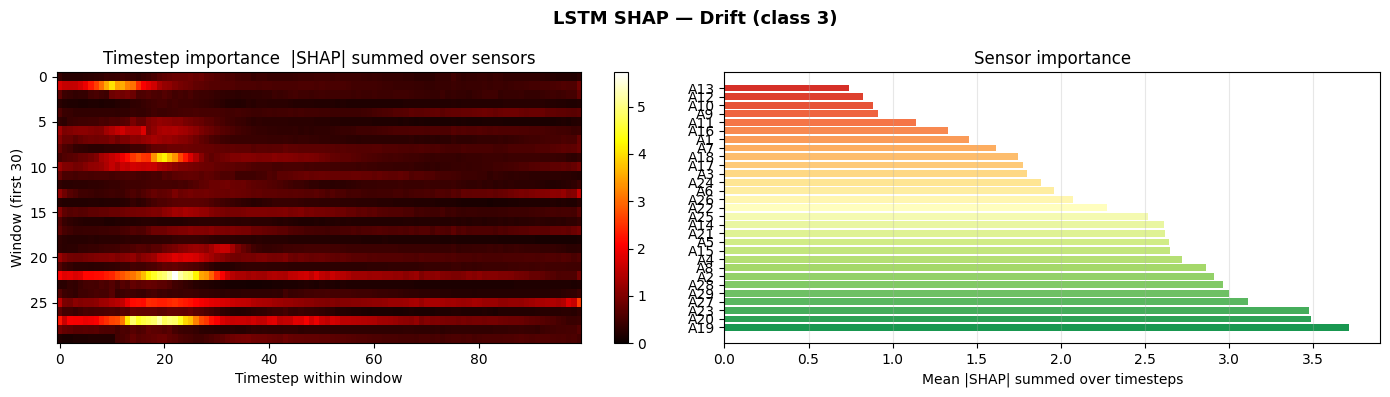

  LSTM SHAP: class 4 (Intermittent)  50 windows …


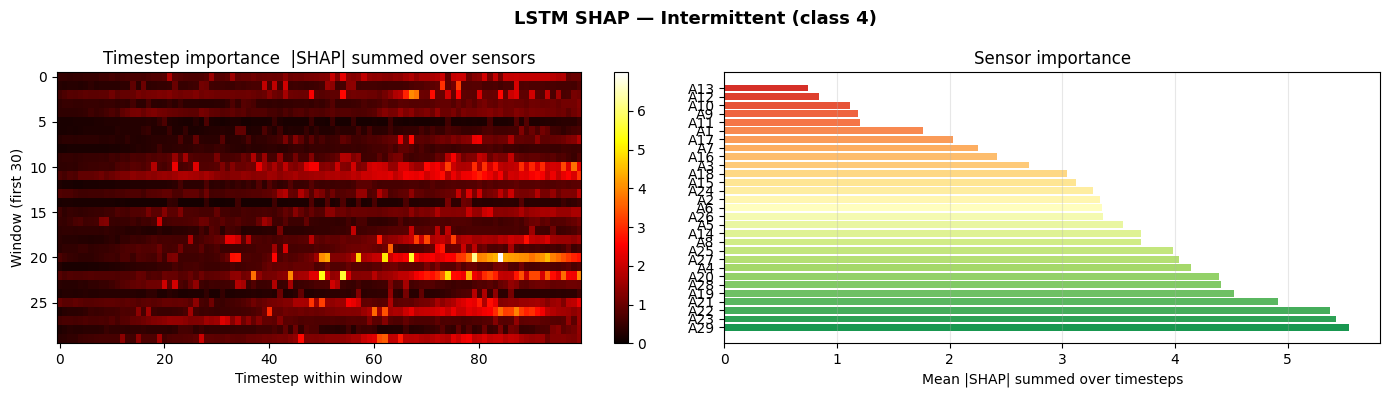

  LSTM SHAP: class 5 (Compound)  50 windows …


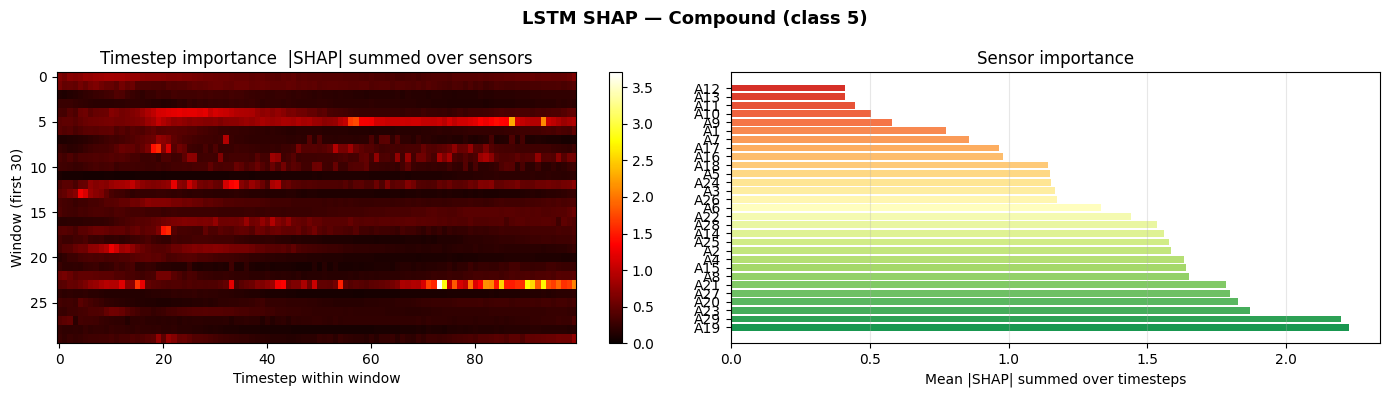

  LSTM SHAP: class 6 (MultiSensor)  50 windows …


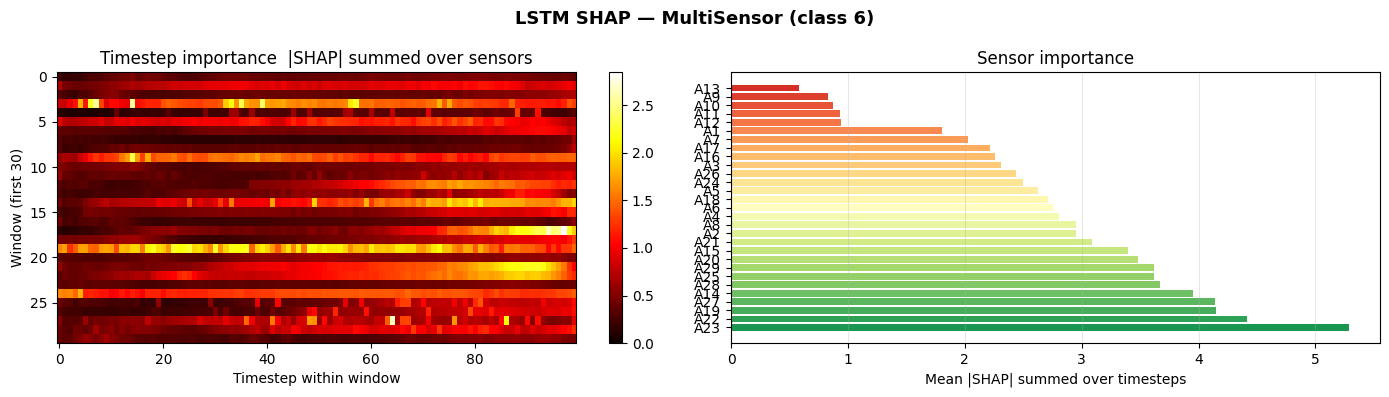


── Transformer SHAP ──────────────────────────────────────────
  Transformer SHAP: class 1 (Bias)  50 windows …


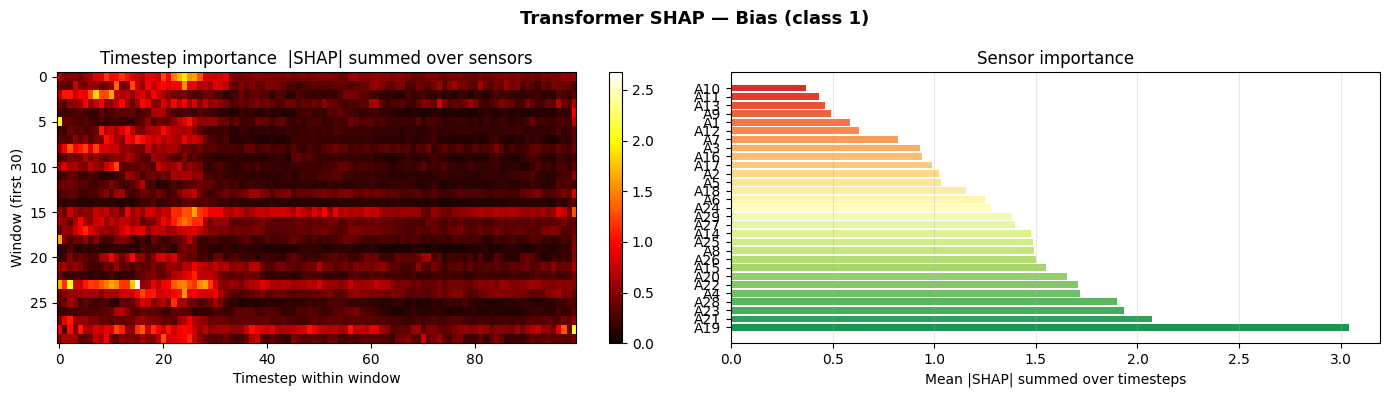

  Transformer SHAP: class 2 (Scaling)  50 windows …


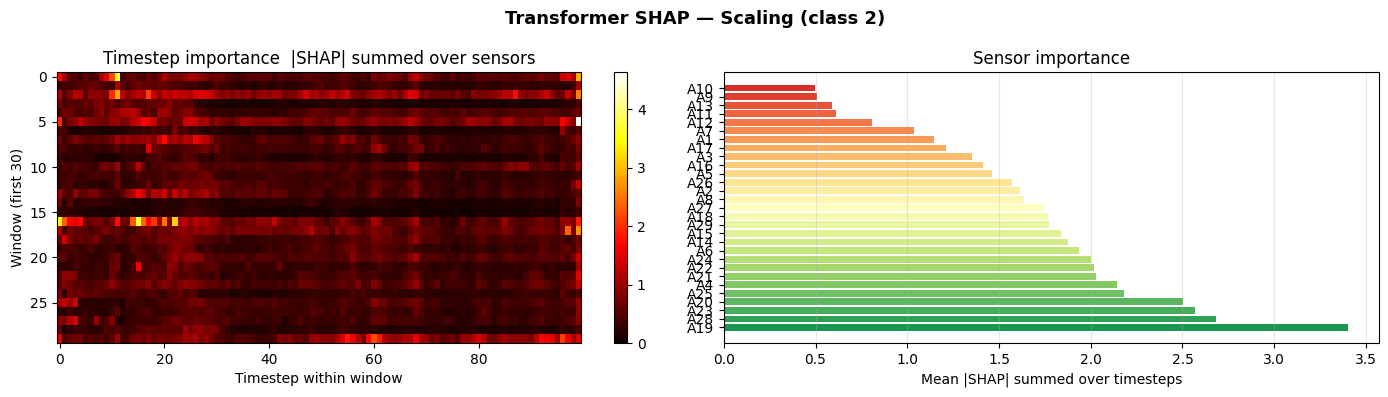

  Transformer SHAP: class 3 (Drift)  50 windows …


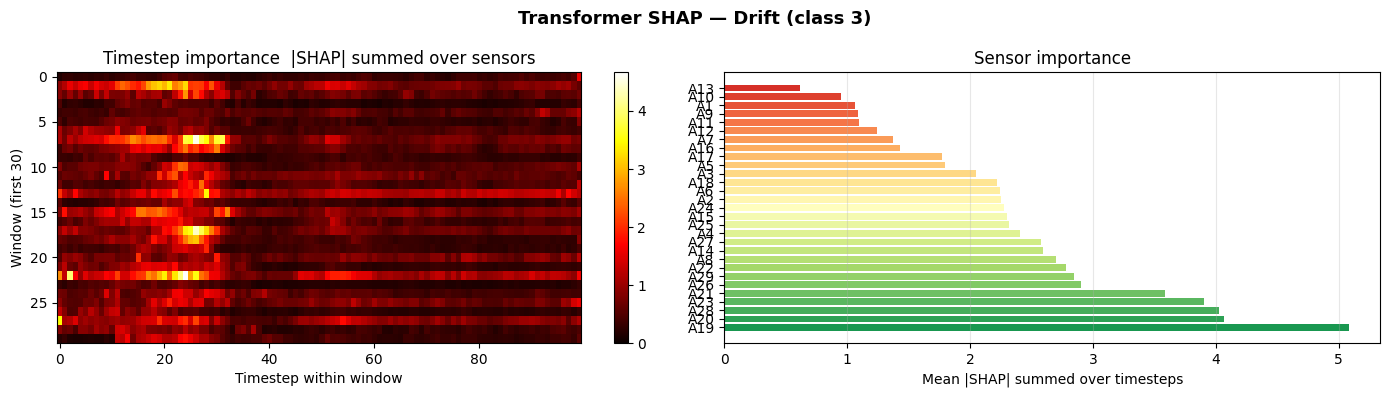

  Transformer SHAP: class 4 (Intermittent)  50 windows …


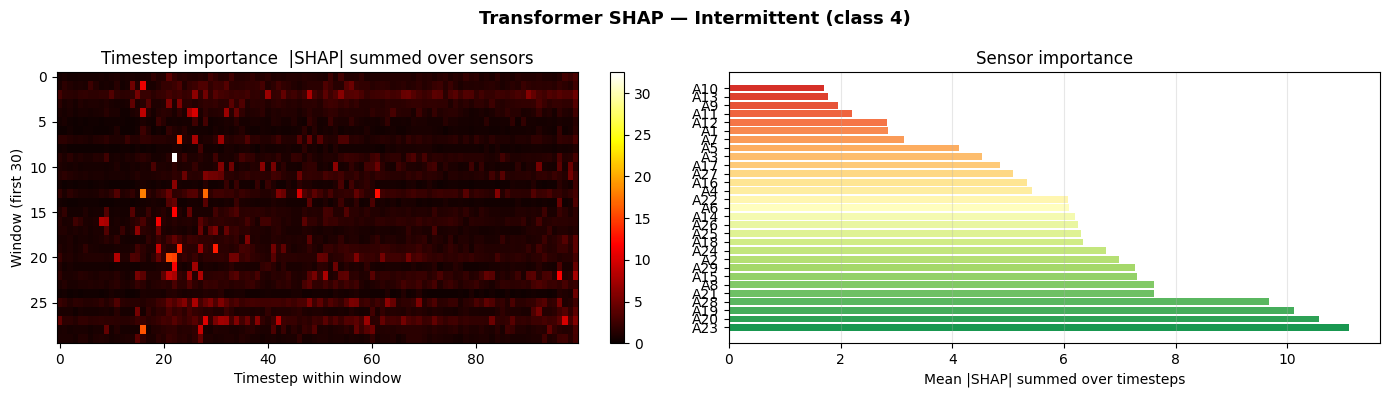

  Transformer SHAP: class 5 (Compound)  50 windows …


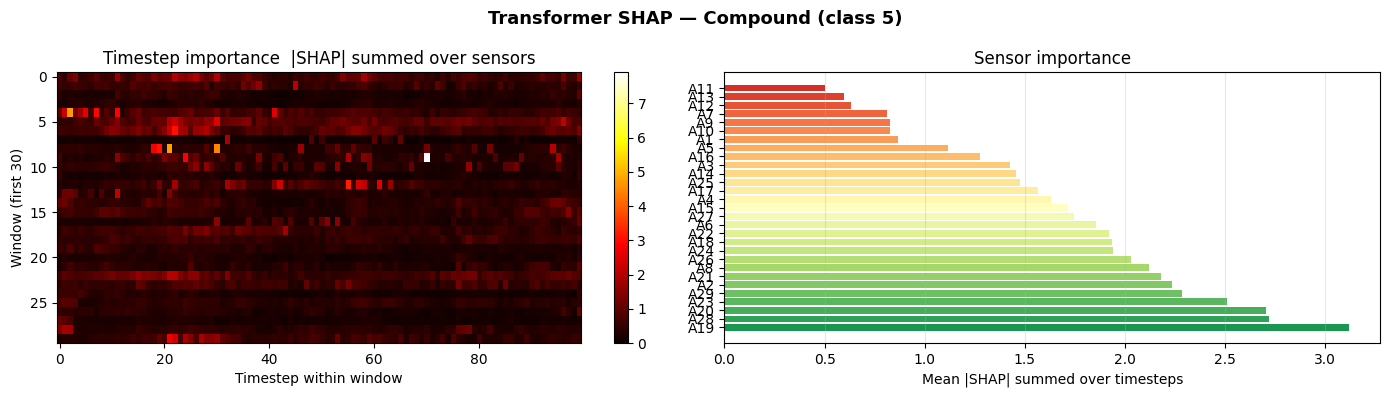

  Transformer SHAP: class 6 (MultiSensor)  50 windows …


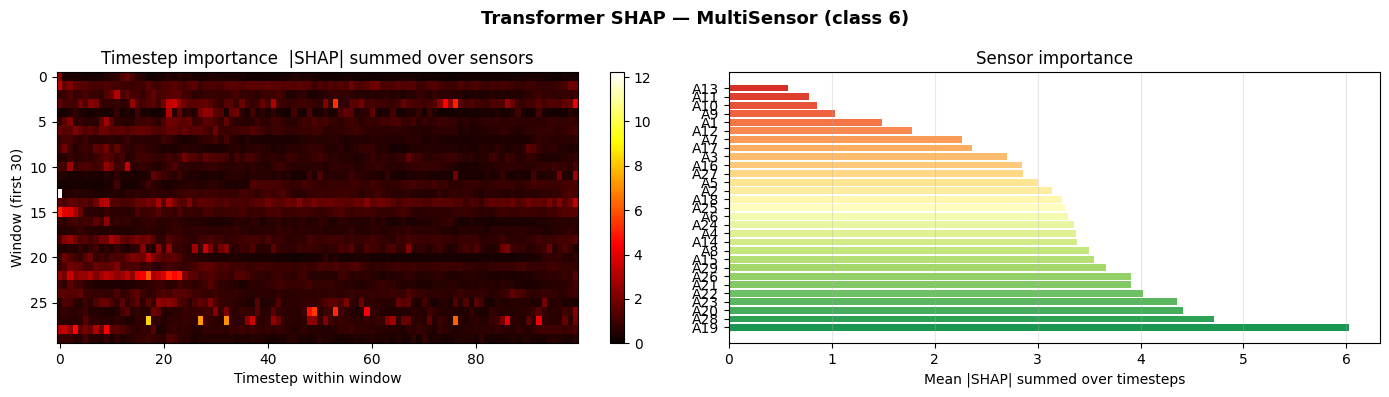


Sequence SHAP plots complete.


In [10]:
seq_shap_sv = {}   # (model_name, class_idx) → (N, T, S) SHAP values

for seq_name in ('LSTM', 'Transformer'):
    if seq_name not in shap_explainers:
        continue
    seq_expl, X_input = shap_explainers[seq_name]
    print(f'\n── {seq_name} SHAP ──────────────────────────────────────────')

    for class_idx in sorted(np.unique(y_fault)):
        class_name = label_names.get(class_idx, str(class_idx))
        if class_idx == 0:
            continue
        mask   = y_fault == class_idx
        X_cls  = X_input[mask][:N_EXPLAIN]
        if len(X_cls) < 5:
            continue

        print(f'  {seq_name} SHAP: class {class_idx} ({class_name})  {len(X_cls)} windows …')
        sv, _ = seq_expl.explain(X_cls, top_k=TOP_K_FEATS, class_idx=int(class_idx))
        # sv shape: (N, T, S) or (N, T, 2S) if USE_RESIDUAL
        # Use only the raw sensor channels (first S columns)
        S_raw = len(sensor_cols)
        sv_raw = sv[:, :, :S_raw]   # (N, T, S)
        seq_shap_sv[(seq_name, class_idx)] = sv_raw

        # ── Plot 1: Mean timestep importance across windows ────────────────
        ts_imp  = SHAPExplainer.timestep_importance(sv_raw)   # (N, T)
        sen_imp = SHAPExplainer.sensor_importance(sv_raw)     # (N, S)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(f'{seq_name} SHAP — {class_name} (class {class_idx})',
                     fontsize=13, fontweight='bold')

        # Left: timestep importance heatmap (windows × timesteps)
        n_show = min(30, len(ts_imp))
        im0 = axes[0].imshow(ts_imp[:n_show], aspect='auto', cmap='hot',
                              interpolation='nearest', vmin=0)
        axes[0].set_xlabel('Timestep within window')
        axes[0].set_ylabel(f'Window (first {n_show})')
        axes[0].set_title('Timestep importance  |SHAP| summed over sensors')
        plt.colorbar(im0, ax=axes[0])

        # Right: mean sensor importance bar chart
        mean_sen = sen_imp.mean(axis=0)   # (S,)
        sort_idx = np.argsort(mean_sen)[::-1]
        colors_  = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, S_raw))
        axes[1].barh([sensor_cols[i] for i in sort_idx], mean_sen[sort_idx],
                     color=colors_)
        axes[1].set_xlabel('Mean |SHAP| summed over timesteps')
        axes[1].set_title('Sensor importance')
        axes[1].grid(axis='x', alpha=0.3)

        plt.tight_layout()
        fname = f'{PLOT_DIR}/nb4_{seq_name.lower()}_shap_{class_name.lower()}.png'
        plt.savefig(fname, dpi=120)
        plt.show()

print('\nSequence SHAP plots complete.')

## 4 — Cross-model sensor importance comparison

For each fault class, compare which sensors each model thinks are important.
Useful for checking whether LSTM/Transformer agree with the ANN.

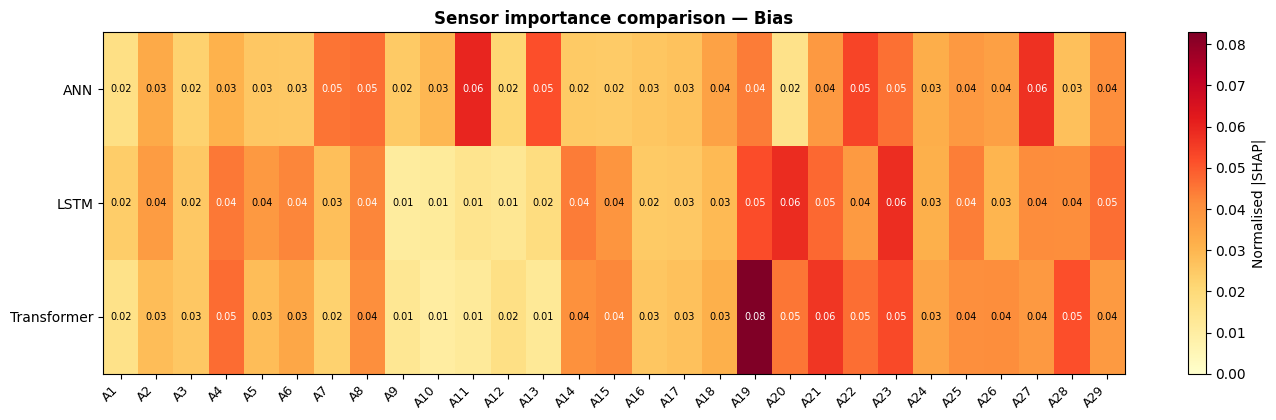

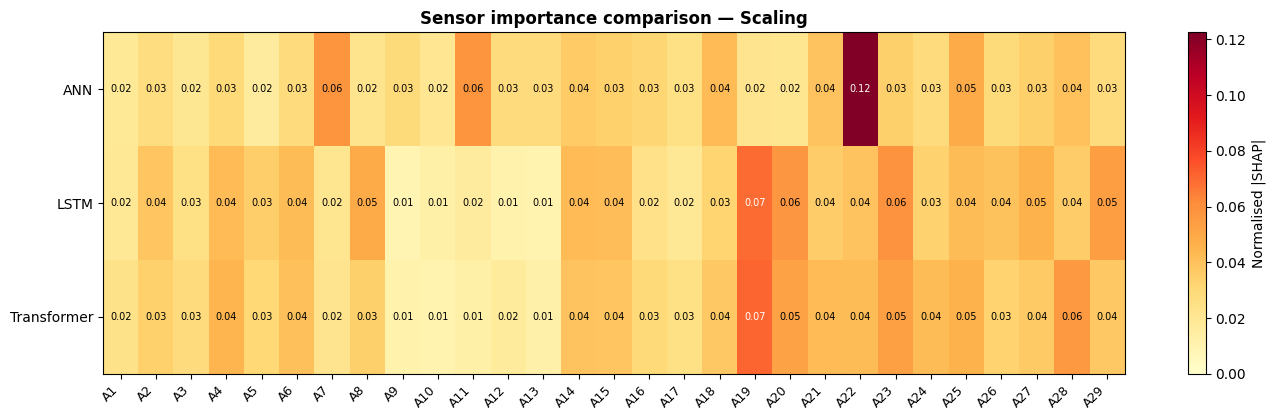

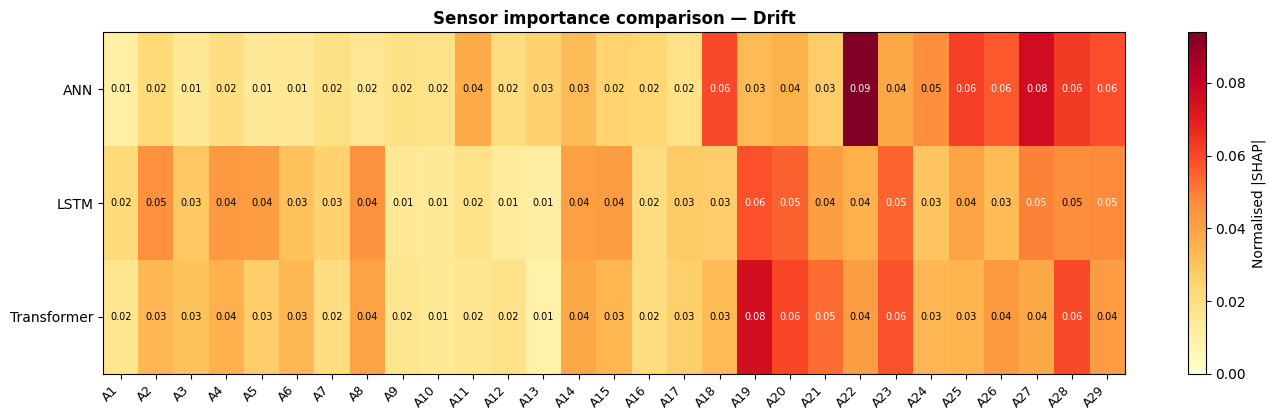

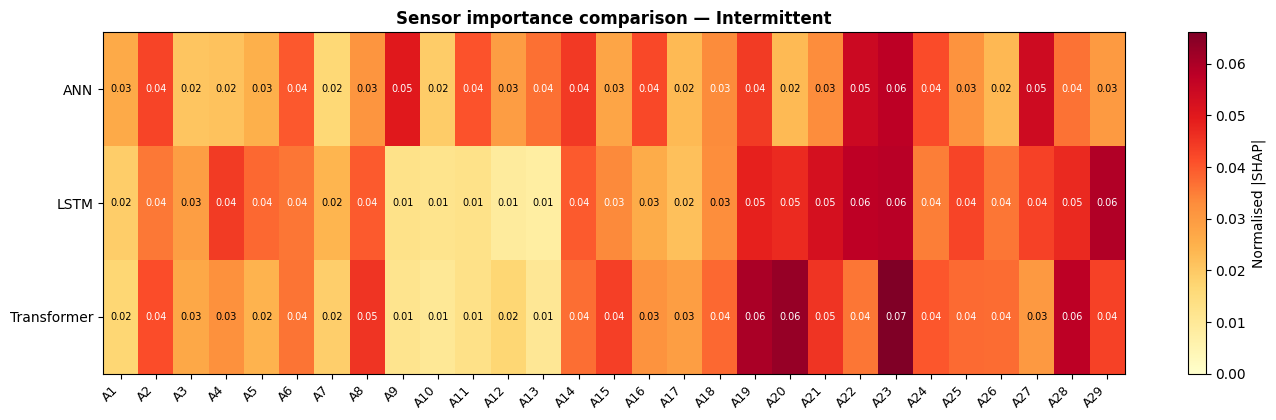

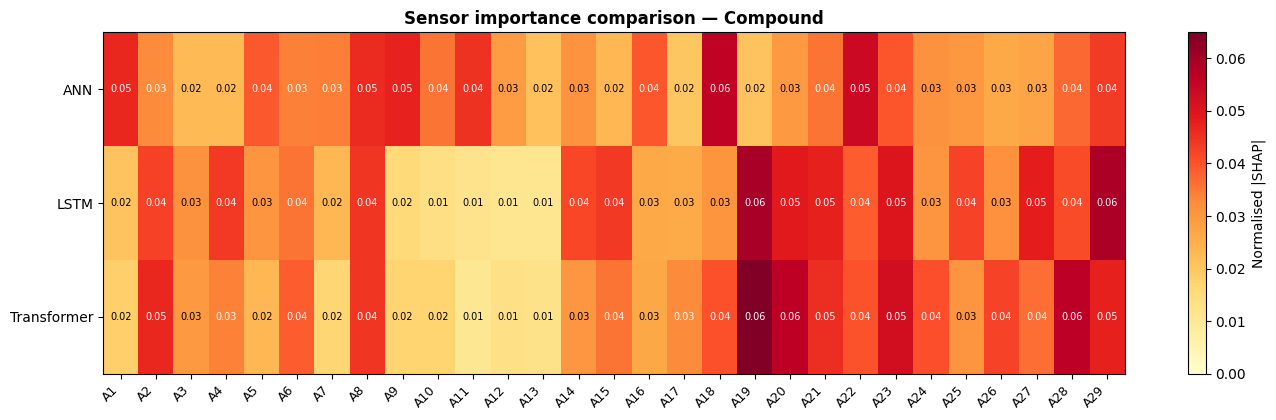

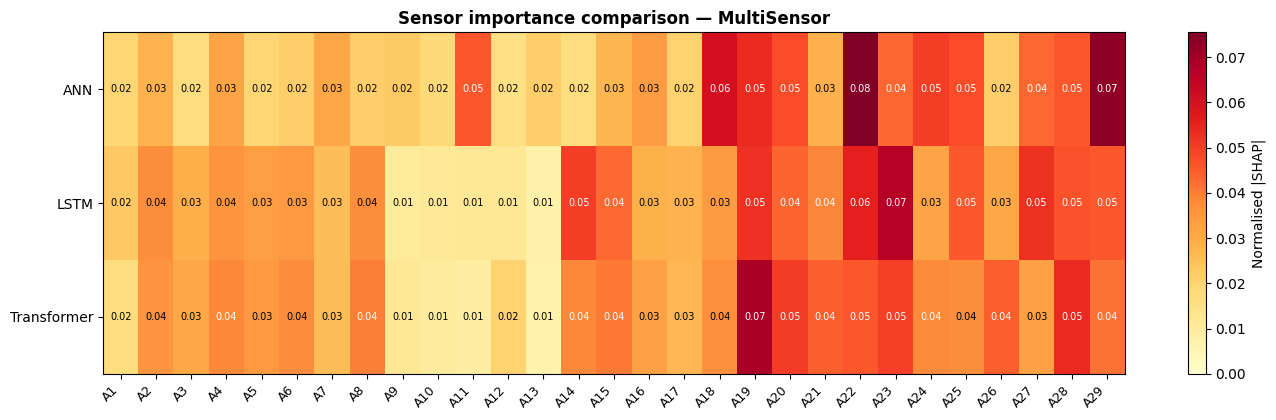

In [11]:
# Build a (model, sensor) importance matrix per fault class
fault_classes = [c for c in sorted(np.unique(y_fault)) if c != 0]

for class_idx in fault_classes:
    class_name = label_names.get(class_idx, str(class_idx))
    entries = {}

    # ANN: use UMAP / residual features — aggregate by sensor
    if class_idx in ann_shap_sv:
        sv = ann_shap_sv[class_idx]          # (N, F)
        feat_names = SHAPExplainer.feature_names(sensor_cols, n_fft_peaks=3)
        # Sum |SHAP| per sensor (all features belonging to that sensor)
        S = len(sensor_cols)
        feats_per_sensor = len(feat_names) // S if S else 1
        mean_abs  = np.abs(sv).mean(axis=0)
        # Truncate to stat+FFT features only (ignore UMAP + residuals at tail)
        n_stat    = S * (4 + 3)   # 4 stats + 3 FFT peaks per sensor
        stat_part = mean_abs[:n_stat].reshape(S, -1).sum(axis=1)   # (S,)
        entries['ANN'] = stat_part / (stat_part.sum() + 1e-12)

    for seq_name in ('LSTM', 'Transformer'):
        key = (seq_name, class_idx)
        if key in seq_shap_sv:
            sv  = seq_shap_sv[key]            # (N, T, S)
            sen = SHAPExplainer.sensor_importance(sv).mean(axis=0)   # (S,)
            entries[seq_name] = sen / (sen.sum() + 1e-12)

    if len(entries) < 2:
        continue   # need at least two models to compare

    model_names = list(entries.keys())
    mat = np.array([entries[m] for m in model_names])   # (n_models, S)

    fig, ax = plt.subplots(figsize=(14, 2.5 + 0.6 * len(model_names)))
    im = ax.imshow(mat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=mat.max())
    ax.set_xticks(range(len(sensor_cols)))
    ax.set_xticklabels(sensor_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(model_names)))
    ax.set_yticklabels(model_names, fontsize=10)
    ax.set_title(f'Sensor importance comparison — {class_name}',
                 fontsize=12, fontweight='bold')
    for r in range(len(model_names)):
        for c in range(len(sensor_cols)):
            ax.text(c, r, f'{mat[r,c]:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if mat[r,c] < 0.5*mat.max() else 'white')
    plt.colorbar(im, ax=ax, label='Normalised |SHAP|')
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/nb4_sensor_comparison_{class_name.lower()}.png', dpi=130)
    plt.show()

## 5 — Per-class ranking summary (all models)

In [12]:
print('Top-5 most important sensors per fault class')
print('=' * 60)

for class_idx in fault_classes:
    class_name = label_names.get(class_idx, str(class_idx))
    print(f'\n{class_name} (class {class_idx}):')

    # ANN
    if class_idx in ann_shap_sv:
        sv  = ann_shap_sv[class_idx]
        ma  = np.abs(sv).mean(axis=0)
        fn  = SHAPExplainer.feature_names(sensor_cols, n_fft_peaks=3)
        top = np.argsort(ma)[::-1][:5]
        names_top = [fn[i] for i in range(0, len(top))]
        print(f'  ANN   : {names_top}')

    for seq_name in ('LSTM', 'Transformer'):
        key = (seq_name, class_idx)
        if key in seq_shap_sv:
            sv  = seq_shap_sv[key]
            sen = SHAPExplainer.sensor_importance(sv).mean(axis=0)
            top = np.argsort(sen)[::-1][:5]
            print(f'  {seq_name:12s}: {[sensor_cols[i] for i in top]}')

Top-5 most important sensors per fault class

Bias (class 1):
  ANN   : ['A1_mean', 'A1_std', 'A1_skew', 'A1_kurt', 'A1_fft_1']
  LSTM        : ['A20', 'A23', 'A19', 'A21', 'A29']
  Transformer : ['A19', 'A21', 'A23', 'A28', 'A4']

Scaling (class 2):
  ANN   : ['A1_mean', 'A1_std', 'A1_skew', 'A1_kurt', 'A1_fft_1']
  LSTM        : ['A19', 'A23', 'A20', 'A29', 'A8']
  Transformer : ['A19', 'A28', 'A23', 'A20', 'A25']

Drift (class 3):
  ANN   : ['A1_mean', 'A1_std', 'A1_skew', 'A1_kurt', 'A1_fft_1']
  LSTM        : ['A19', 'A20', 'A23', 'A27', 'A29']
  Transformer : ['A19', 'A20', 'A28', 'A23', 'A21']

Intermittent (class 4):
  ANN   : ['A1_mean', 'A1_std', 'A1_skew', 'A1_kurt', 'A1_fft_1']
  LSTM        : ['A29', 'A23', 'A22', 'A21', 'A19']
  Transformer : ['A23', 'A20', 'A19', 'A28', 'A21']

Compound (class 5):
  ANN   : ['A1_mean', 'A1_std', 'A1_skew', 'A1_kurt', 'A1_fft_1']
  LSTM        : ['A19', 'A29', 'A23', 'A20', 'A27']
  Transformer : ['A19', 'A28', 'A20', 'A23', 'A29']

Multi

## 6 — Save all SHAP values

In [13]:
save_dict = {}

# ANN SHAP values
for c, sv in ann_shap_sv.items():
    save_dict[f'ann_class_{c}'] = sv

# Sequence SHAP values
for (model_name, c), sv in seq_shap_sv.items():
    save_dict[f'{model_name.lower()}_class_{c}'] = sv

if save_dict:
    np.savez_compressed(f'{PROC_DIR}/shap_values.npz', **save_dict)
    print(f'SHAP values saved → {PROC_DIR}/shap_values.npz')
    print(f'Keys: {list(save_dict.keys())}')

print('\n✓ NB4 complete — Proceed to NB5_Diagnosis.ipynb')

SHAP values saved → ../processed_data/shap_values.npz
Keys: ['ann_class_1', 'ann_class_2', 'ann_class_3', 'ann_class_4', 'ann_class_5', 'ann_class_6', 'lstm_class_1', 'lstm_class_2', 'lstm_class_3', 'lstm_class_4', 'lstm_class_5', 'lstm_class_6', 'transformer_class_1', 'transformer_class_2', 'transformer_class_3', 'transformer_class_4', 'transformer_class_5', 'transformer_class_6']

✓ NB4 complete — Proceed to NB5_Diagnosis.ipynb


---
## ↻ Reload Block

In [14]:
# ── Run this block only if kernel was restarted ──────────────────────────────
import sys, os, pickle, warnings, json
import numpy as np, torch
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
from models import (ConvAutoencoder, AETrainer, MultiHeadANN, MultiHeadLSTM,
                    MultiHeadTransformer, MCDropoutWrapper, DEVICE)
from feature_engineering import FeaturePipeline
from explainability import SHAPExplainer
from fault_engine import FAULT_LABELS

PROC_DIR = '../processed_data'; CKPT_DIR = '../checkpoints'; PLOT_DIR = '../plots'
label_names = {0:'Nominal',1:'Bias',2:'Scaling',3:'Drift',
               4:'Intermittent',5:'Compound',6:'MultiSensor',7:'SystemFault'}

with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f: sensor_cols = pickle.load(f)
with open(f'{CKPT_DIR}/nb3_meta.json')           as f: meta = json.load(f)
HEAD_TYPE = meta['head_type']; USE_RESIDUAL = meta['use_residual']
N_SENSORS = meta['n_sensors']; WINDOW_SIZE = meta['window_size']
N_FAULT_TYPES = meta['n_fault_types']

_raw = np.load(f'{PROC_DIR}/augmented_dataset_with_recon.npz')
X_dataset = _raw['X']; X_recon_all = _raw['X_rec']
y_fault = _raw['y_f']; y_sensor = _raw['y_s']; y_mag = _raw['y_m']

with open(f'{CKPT_DIR}/shap_explainers.pkl', 'rb') as f:
    shap_explainers = pickle.load(f)

_sv = np.load(f'{PROC_DIR}/shap_values.npz', allow_pickle=True)
ann_shap_sv = {int(k.split('_')[-1]): _sv[k] for k in _sv if k.startswith('ann_')}
seq_shap_sv = {}
for k in _sv:
    if k.startswith('lstm_') or k.startswith('transformer_'):
        parts = k.rsplit('_', 1)
        model_n = 'LSTM' if k.startswith('lstm') else 'Transformer'
        seq_shap_sv[(model_n, int(parts[-1]))] = _sv[k]

print('✓ All artefacts reloaded')
print(f'  Explainers: {list(shap_explainers.keys())}')
print(f'  ANN SHAP classes: {sorted(ann_shap_sv.keys())}')
print(f'  Seq SHAP keys   : {sorted(seq_shap_sv.keys())}')

✓ All artefacts reloaded
  Explainers: ['ANN', 'LSTM', 'Transformer']
  ANN SHAP classes: [1, 2, 3, 4, 5, 6]
  Seq SHAP keys   : [('LSTM', 1), ('LSTM', 2), ('LSTM', 3), ('LSTM', 4), ('LSTM', 5), ('LSTM', 6), ('Transformer', 1), ('Transformer', 2), ('Transformer', 3), ('Transformer', 4), ('Transformer', 5), ('Transformer', 6)]
